# HARPS continuum normalization with [SUPPNet](https://github.com/RozanskiT/suppnet)

Reads flux and wavelength arrays from `harps_data.zarr` (produced by `harps_read.ipynb`),
runs the SUPPNet neural continuum fitter, and writes
`normalized_wave`, `normalized_flux`, and `continuum` back into the same zarr group.

**Prerequisites**

1. Run `harps_read.ipynb` first so `harps_data.zarr` exists with `wavelengths`, `fluxes`,
   `bjds`, and `raw_source_files`.
2. Create the conda env (one-time). From this directory:

```bash
bash setup_suppnet_env.sh
```

   That clones `~/code/suppnet` if needed, creates **`suppnet-env`**, installs SUPPNet
   editable, and registers the Jupyter kernel **Python (suppnet)**. On Apple Silicon it
   uses `environment-macos-arm64.yml` (upstream `environment.yml` is Linux-oriented).

3. In Jupyter, select kernel **Python (suppnet)** and run the notebook.

**Apple Silicon:** upstream `environment.yml` pins TensorFlow 2.4, which **crashes the kernel** on
`model.predict` (not OOM). `setup_suppnet_env.sh` upgrades to **tensorflow-macos ≥2.9** on arm64.
Expect ~1–2 min per HARPS exposure (~25 min for 21 spectra).

**Headless run** (no Jupyter / nbconvert needed):

```bash
cd tutorial/paper_results/tz_fornacis
conda activate suppnet-env
python harps_suppnet_normalize.py
```

**Zarr version:** `harps_read.ipynb` writes **Zarr v3**; the official `suppnet-env` (Python 3.8) only has **zarr 2.x**.
On first open this notebook auto-converts to `harps_data_zarr2.zarr` via the **`astro`** conda env
(one-time; needs `conda run -n astro` on your PATH). Normalized arrays are written to that v2 copy.
Alternatively use a Python ≥3.11 suppnet env with zarr ≥3 and open `harps_data.zarr` directly.

**Notes**

- HARPS sampling is ~0.01 Å; SUPPNet default internal resampling is 0.05 Å (see
  [`--sampling`](https://github.com/RozanskiT/suppnet)).
- Wavelengths are already in the observer barycentric frame (BERV applied by the HARPS DRS);
  do not apply BERV again.
- Optional: set `EXPORT_TXT_DIR` to also write `spectrum<i>.all` files for manual QC in the
  SUPPNet GUI (`SUPPNET --path spectrum<i>.all`).

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import zarr
from tqdm.auto import tqdm

%matplotlib inline

# --- paths (run this notebook from tutorial/paper_results/tz_fornacis/)
WORKDIR = Path('.').resolve()
ZARR_PATH = WORKDIR / 'harps_data_zarr2.zarr'  # after first conversion
SUPPNET_REPO = Path(os.environ.get('SUPPNET_REPO', '/Users/mjablons/code/suppnet')).expanduser()

# SUPPNet hyper-parameters (see suppnet --help)
RESAMPLING_STEP = 0.05   # Å; HARPS is ~0.01 Å — 0.05 is the SUPPNet default
WHICH_WEIGHTS = 'active'  # 'active' | 'synth' | 'emission'

# Optional: also write .all files for interactive QC
EXPORT_TXT_DIR = None  # e.g. WORKDIR / 'normalized_spectra'

if str(SUPPNET_REPO) not in sys.path and SUPPNET_REPO.is_dir():
    sys.path.insert(0, str(SUPPNET_REPO))

import tensorflow as tf

os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')
_tf_major, _tf_minor = (int(x) for x in tf.__version__.split('.')[:2])
if (_tf_major, _tf_minor) < (2, 9):
    raise RuntimeError(
        f'TensorFlow {tf.__version__} aborts on Apple Silicon during SUPPNet predict '
        '(grappler gflops bug). Upgrade in this env:\n'
        '  pip install "tensorflow-macos>=2.9.2,<2.10" "tensorflow-metal>=0.5.1,<0.6"'
    )
for _gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(_gpu, True)

try:
    from suppnet.NN_utility import get_suppnet, get_smoothed_continuum
except ImportError as exc:
    raise ImportError(
        'Cannot import suppnet. Clone https://github.com/RozanskiT/suppnet, '
        'create conda env (environment.yml), pip install -e ., then set '
        f'SUPPNET_REPO={SUPPNET_REPO} or activate suppnet-env in this kernel.'
    ) from exc

print(f'WORKDIR:     {WORKDIR}')
print(f'ZARR_PATH:   {ZARR_PATH}')
print(f'SUPPNET_REPO: {SUPPNET_REPO}')
print(f'tensorflow:  {tf.__version__}')

/Users/mjablons/anaconda3/envs/suppnet-env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


WORKDIR:     /Users/mjablons/code/spice/tutorial/paper_results/tz_fornacis
ZARR_PATH:   /Users/mjablons/code/spice/tutorial/paper_results/tz_fornacis/harps_data_zarr2.zarr
SUPPNET_REPO: /Users/mjablons/code/suppnet
tensorflow:  2.9.2


In [2]:
def finite_spectrum(wave_row, flux_row):
    """Strip NaN padding from one zarr row."""
    w = np.asarray(wave_row, dtype=float)
    f = np.asarray(flux_row, dtype=float)
    mask = np.isfinite(w) & np.isfinite(f)
    return w[mask], f[mask]


def mask_zero_only_gaps(wave, flux, normed_flux, continuum, **extra):
    """Match read_harps_normalized.ipynb: rows where all value columns are 0 → NaN."""
    df = pd.DataFrame({
        'wave': wave,
        'flux': flux,
        'normed_flux': normed_flux,
        'continuum': continuum,
        **extra,
    })
    zero_gap = df[['flux', 'normed_flux', 'continuum']].eq(0).all(axis=1)
    df.loc[zero_gap, ['normed_flux', 'continuum']] = np.nan
    return df


def suppnet_normalize_row(wave, flux, nn):
    """Run SUPPNet on one exposure; return arrays on the original wavelength grid."""
    if wave.size < 100:
        raise ValueError(f'spectrum too short ({wave.size} points)')
    flux = np.asarray(flux, dtype=float).copy()
    median = np.nanmedian(flux)
    if not np.isfinite(median) or median == 0:
        raise ValueError('non-finite or zero flux median')
    flux /= median

    cont, cont_err, seg, seg_err = nn.normalize(wave, flux)
    cont_smo = get_smoothed_continuum(wave, cont, cont_err)
    normed = flux / cont_smo
    normed_err = cont_err / cont_smo

    df = mask_zero_only_gaps(
        wave, flux, normed, cont_smo,
        normed_error=normed_err,
        continuum_raw=cont,
        continuum_err=cont_err,
        segmentation=seg,
        segmentation_err=seg_err,
    )
    return df


def is_zarr_v3_store(path: Path) -> bool:
    meta = path / 'zarr.json'
    if not meta.is_file():
        return False
    import json
    return json.loads(meta.read_text()).get('zarr_format') == 3


def ensure_zarr2_copy(src: Path, dst: Path) -> None:
    """One-time v3 → v2 conversion using the astro env (zarr>=3)."""
    import subprocess
    import textwrap

    if dst.is_dir() and dst.stat().st_mtime >= src.stat().st_mtime:
        return

    print(f'Converting {src.name} (Zarr v3) → {dst.name} (Zarr v2) for this kernel…')
    code = textwrap.dedent(f'''
        import json
        import shutil
        from pathlib import Path
        import zarr
        import numpy as np
        src, dst = Path({str(src)!r}), Path({str(dst)!r})
        if dst.exists():
            shutil.rmtree(dst)
        g3 = zarr.open_group(src, mode='r')
        g2 = zarr.open_group(dst, mode='w', zarr_format=2)
        for key in g3.array_keys():
            g2.create_array(key, data=np.asarray(g3[key]))
        for key, val in g3.attrs.asdict().items():
            g2.attrs[key] = val
        print('converted', len(list(g3.array_keys())), 'arrays')
    ''')
    subprocess.check_call(
        ['conda', 'run', '-n', 'astro', 'python', '-c', code],
        cwd=str(src.parent),
    )


def open_harps_store(path: Path, mode: str = 'r+'):
    """Open harps_data.zarr; auto-convert to harps_data_zarr2.zarr if kernel has zarr<3."""
    path = Path(path)
    if not path.is_dir():
        raise FileNotFoundError(f'{path} not found — run harps_read.ipynb first.')

    zarr_major = int(zarr.__version__.split('.')[0])
    if is_zarr_v3_store(path) and zarr_major < 3:
        v2_path = path.with_name('harps_data_zarr2.zarr')
        ensure_zarr2_copy(path, v2_path)
        path = v2_path
        print(f'Using Zarr v2 mirror: {path}')

    try:
        return zarr.open_group(path, mode=mode)
    except zarr.errors.GroupNotFoundError as exc:
        raise RuntimeError(
            f'Cannot open {path} with zarr {zarr.__version__}. '
            'harps_read.ipynb writes Zarr v3; use conda env astro (zarr>=3) or '
            'recreate suppnet-env with Python>=3.11 (see setup_suppnet_env.sh).'
        ) from exc


def write_zarr_array(group, name: str, data: np.ndarray, fill_value=np.nan) -> None:
    """Write array with zarr v2 or v3 API."""
    if hasattr(group, 'create_array'):
        group.create_array(name, data=data, overwrite=True, fill_value=fill_value)
    else:
        if name in group:
            del group[name]
        group.create_dataset(name, data=data, fill_value=fill_value)


def save_all_file(df, path):
    """Write SUPPNet .all format (same columns as the GUI / NN_utility)."""
    out = pd.DataFrame({
        'wave': df['wave'],
        'flux': df['flux'],
        'normed_flux': df['normed_flux'],
        'normed_error': df['normed_error'],
        'smoothed_continuum': df['continuum'],
        'continuum': df['continuum_raw'],
        'continuum_err': df['continuum_err'],
        'segmentation': df['segmentation'],
        'segmentation_err': df['segmentation_err'],
    })
    gap = out['flux'].eq(0)
    out.loc[gap, out.columns != 'wave'] = 0.0
    out.to_csv(path, sep=' ', index=False)

In [3]:
print(f'zarr version: {zarr.__version__}')
store = open_harps_store(ZARR_PATH, mode='r+')
store.tree()

raw_source_files = list(store.attrs.get('raw_source_files', []))
if not raw_source_files:
    raise RuntimeError(
        'harps_data.zarr has no raw_source_files — re-run harps_read.ipynb.'
    )

nrows = store['wavelengths'].shape[0]
print(f'{nrows} spectra; first file: {raw_source_files[0]}')

zarr version: 2.16.1
21 spectra; first file: ADP.2014-09-23T11:00:36.353.fits


In [4]:
print('Loading SUPPNet model (TensorFlow)…')
nn = get_suppnet(
    resampling_step=RESAMPLING_STEP,
    step_size=256,
    norm_only=False,
    which_weights=WHICH_WEIGHTS,
)
print('Model ready.')

Loading SUPPNet model (TensorFlow)…


Start creating SUPPNet model!
Metal device set to: Apple M2

systemMemory: 8.00 GB
maxCacheSize: 2.67 GB

SUPPNet model created!
Start loading weights!
SUPPNet (active)
Weights loaded!
Model ready.


In [5]:
import gc

if EXPORT_TXT_DIR is not None:
    EXPORT_TXT_DIR = Path(EXPORT_TXT_DIR)
    EXPORT_TXT_DIR.mkdir(parents=True, exist_ok=True)

normalized_wave_rows = []
normalized_flux_rows = []
continuum_rows = []
failed = []

for i in tqdm(range(nrows), desc='SUPPNet'):
    wave, flux = finite_spectrum(store['wavelengths'][i], store['fluxes'][i])
    if wave.size == 0:
        failed.append((i, 'no finite pixels'))
        normalized_wave_rows.append(np.full(store['wavelengths'].shape[1], np.nan))
        normalized_flux_rows.append(np.full(store['wavelengths'].shape[1], np.nan))
        continuum_rows.append(np.full(store['wavelengths'].shape[1], np.nan))
        continue
    try:
        df = suppnet_normalize_row(wave, flux, nn)
    except Exception as exc:
        failed.append((i, repr(exc)))
        ncols = store['wavelengths'].shape[1]
        normalized_wave_rows.append(np.full(ncols, np.nan))
        normalized_flux_rows.append(np.full(ncols, np.nan))
        continuum_rows.append(np.full(ncols, np.nan))
        continue

    if EXPORT_TXT_DIR is not None:
        save_all_file(df, EXPORT_TXT_DIR / f'spectrum{i}.all')

    # Pad back to the zarr row width for storage
    ncols = store['wavelengths'].shape[1]
    w_pad = np.full(ncols, np.nan)
    f_pad = np.full(ncols, np.nan)
    c_pad = np.full(ncols, np.nan)
    wv = df['wave'].values
    n = wv.size
    w_pad[:n] = wv
    f_pad[:n] = df['normed_flux'].values
    c_pad[:n] = df['continuum'].values  # smoothed continuum
    normalized_wave_rows.append(w_pad)
    normalized_flux_rows.append(f_pad)
    continuum_rows.append(c_pad)
    gc.collect()

normalized_wave_arr = np.asarray(normalized_wave_rows)
normalized_flux_arr = np.asarray(normalized_flux_rows)
continuum_arr = np.asarray(continuum_rows)

print(f'done: {nrows - len(failed)}/{nrows} OK, {len(failed)} failed')
if failed:
    for row, msg in failed[:10]:
        print(f'  row {row}: {msg}')

SUPPNet:   0%|          | 0/21 [00:00<?, ?it/s]

9/9 [==============================] - 54s 3s/step


SUPPNet:   5%|▍         | 1/21 [01:07<22:28, 67.43s/it]

9/9 [==============================] - 27s 2s/step


SUPPNet:  10%|▉         | 2/21 [01:35<14:05, 44.52s/it]

...

9/9 [==============================] - 18s 2s/step


SUPPNet:  95%|█████████▌| 20/21 [08:05<00:18, 18.82s/it]

9/9 [==============================] - 15s 2s/step


SUPPNet: 100%|██████████| 21/21 [08:21<00:00, 23.87s/it]


done: 21/21 OK, 0 failed


In [8]:
write_zarr_array(store, 'normalized_wave', normalized_wave_arr, fill_value=np.nan)
write_zarr_array(store, 'normalized_flux', normalized_flux_arr, fill_value=np.nan)
write_zarr_array(store, 'continuum', continuum_arr, fill_value=np.nan)
store.attrs['normalized_flux_source_files'] = [
    f'spectrum{i}.all' for i in range(nrows)
]
store.attrs['normalized_rows_aligned_to_raw'] = True
store.attrs['suppnet_resampling_step_A'] = RESAMPLING_STEP
store.attrs['suppnet_weights'] = WHICH_WEIGHTS

print('Wrote normalized_wave, normalized_flux, continuum to', ZARR_PATH)

Wrote normalized_wave, normalized_flux, continuum to /Users/mjablons/code/spice/tutorial/paper_results/tz_fornacis/harps_data_zarr2.zarr


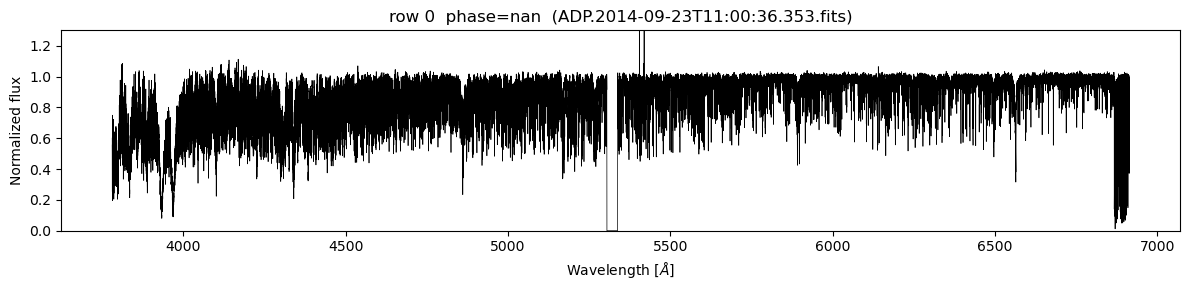

In [9]:
# Quick QC: one exposure
import matplotlib.pyplot as plt

idx = 0
w, f = finite_spectrum(store['normalized_wave'][idx], store['normalized_flux'][idx])
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(w, f, 'k-', lw=0.5)
ax.set_xlabel(r'Wavelength [$\AA$]')
ax.set_ylabel('Normalized flux')
phase = float(store['phases'][idx]) if 'phases' in store else np.nan
ax.set_title(f'row {idx}  phase={phase:.3f}  ({raw_source_files[idx]})')
ax.set_ylim(0, 1.3)
plt.tight_layout()
plt.show()

## Next steps

- Run `phase_harps.ipynb` if `phases` are not yet set (Gallenne et al. 2016 ephemeris).
- Compare to SPICE in `tz_fornacis_eclipse_plots.ipynb`.
- For manual touch-up, open an exported `.all` file with
  `SUPPNET --path normalized_spectra/spectrum0.all` (GUI; model not reloaded).